# Training

> **Before running:** `Runtime → Change runtime type → T4 GPU`

---
## Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/prajwl7676/mini-clip-DLAI.git

%cd /content/mini-clip-DLAI
!pip install -q -r requirements.txt

import sys, os
sys.path.insert(0, '/content/mini-clip-DLAI')

Mounted at /content/drive
Cloning into 'mini-clip-DLAI'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 41 (delta 11), reused 35 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 6.91 MiB | 16.18 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/mini-clip-DLAI
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 117.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 M

In [1]:
%cd /content/mini-clip-DLAI

/content/mini-clip-DLAI


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from transformers import DistilBertTokenizer

from src.model_architecture import CLIPModel
from src.dataset import FlickrDataset, get_transform, build_loaders
from src.loss    import clip_loss
from src.train   import train_epoch, validate, save_checkpoint, load_checkpoint

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


---
## Cell 2 — Configuration



In [3]:
import os
# Hyperparameters
CFG = {
    # Data
    'total_samples': 10_000,
    'n_train':        8_000,
    'n_val':          1_000,
    # n_test = total - n_train - n_val = 1000

    # Model
    'embedding_dim':  256,
    'max_length':      77,

    # Training
    'batch_size':      64,
    'num_epochs':      15,
    'lr':             1e-4,    # learning rate for encoders
    'lr_head':        1e-3,    # higher lr for projection heads
    'weight_decay':   1e-2,
    'max_grad_norm':   1.0,
    'num_workers':      2,

    # Paths
    'checkpoint_dir': '/content/drive/MyDrive/mini-clip-dlai/checkpoints',
    'best_ckpt_path': '/content/drive/MyDrive/mini-clip-dlai/checkpoints/best.pt',
}

os.makedirs(CFG['checkpoint_dir'], exist_ok=True)
print('Config ready.')
for k, v in CFG.items():
    print(f'  {k:<20} : {v}')

Config ready.
  total_samples        : 10000
  n_train              : 8000
  n_val                : 1000
  embedding_dim        : 256
  max_length           : 77
  batch_size           : 64
  num_epochs           : 15
  lr                   : 0.0001
  lr_head              : 0.001
  weight_decay         : 0.01
  max_grad_norm        : 1.0
  num_workers          : 2
  checkpoint_dir       : /content/drive/MyDrive/mini-clip-dlai/checkpoints
  best_ckpt_path       : /content/drive/MyDrive/mini-clip-dlai/checkpoints/best.pt


---
## Cell 3 — Load data

In [4]:
print('Loading Flickr30k (cached after first run)...')
full_ds = load_dataset('nlphuji/flickr30k', split='test')

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Split
n_train = CFG['n_train']
n_val   = CFG['n_val']
n_total = CFG['total_samples']

train_hf = full_ds.select(range(0, n_train))
val_hf   = full_ds.select(range(n_train, n_train + n_val))
test_hf  = full_ds.select(range(n_train + n_val, n_total))

# Datasets
train_ds = FlickrDataset(train_hf, tokenizer, get_transform(train=True))
val_ds   = FlickrDataset(val_hf,   tokenizer, get_transform(train=False))
test_ds  = FlickrDataset(test_hf,  tokenizer, get_transform(train=False))

# DataLoaders
train_loader, val_loader, test_loader = build_loaders(
    train_ds, val_ds, test_ds,
    batch_size  = CFG['batch_size'],
    num_workers = CFG['num_workers'],
)

print(f'Train : {len(train_ds):,} samples  →  {len(train_loader)} batches')
print(f'Val   : {len(val_ds):,} samples  →  {len(val_loader)} batches')
print(f'Test  : {len(test_ds):,} samples  →  {len(test_loader)} batches')

Loading Flickr30k (cached after first run)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/641 [00:00<?, ?B/s]

flickr30k.py: 0.00B [00:00, ?B/s]

TEST/test/0000.parquet:   0%|          | 0.00/506M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Train : 8,000 samples  →  125 batches
Val   : 1,000 samples  →  16 batches
Test  : 1,000 samples  →  16 batches


---
## Cell 4 — Build model and optimizer

- Encoder weights (pretrained) → small lr `1e-4`
- Projection heads (randomly initialised) → larger lr `1e-3`  
- Temperature τ (scalar) → same as projection heads

In [5]:
model = CLIPModel(embedding_dim=CFG['embedding_dim']).to(device)

# Separate parameter groups with different learning rates
projection_params = (
    list(model.image_encoder.projection.parameters()) +
    list(model.text_encoder.projection.parameters())  +
    [model.log_temperature]
)
encoder_params = [
    p for p in model.parameters()
    if p.requires_grad and not any(p is pp for pp in projection_params)
]

optimizer = torch.optim.AdamW([
    {'params': encoder_params,    'lr': CFG['lr'],      'weight_decay': CFG['weight_decay']},
    {'params': projection_params, 'lr': CFG['lr_head'], 'weight_decay': 0.0},
])

# Cosine annealing: smoothly reduces lr from initial value → 0 over training
# This helps the model settle into a good minimum in the final epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['num_epochs'],
    eta_min=1e-6,
)

# Count parameters
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  ({100*trainable/total:.1f}%)')
print(f'Optimizer ready with {len(optimizer.param_groups)} param groups.')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 118MB/s]


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Total params     : 90,592,833
Trainable params : 44,038,145  (48.6%)
Optimizer ready with 2 param groups.


---
## Cell 5 — Resume from checkpoint (if exists)


In [6]:
loss_history = {'train': [], 'val': []}
start_epoch  = 0
best_val_loss = float('inf')

# Look for the most recent epoch checkpoint
resume_path = None
for ep in range(CFG['num_epochs'] - 1, -1, -1):
    candidate = os.path.join(CFG['checkpoint_dir'], f'epoch_{ep:02d}.pt')
    if os.path.exists(candidate):
        resume_path = candidate
        break

if resume_path:
    print(f'Resuming from: {resume_path}')
    ckpt         = load_checkpoint(model, optimizer, resume_path, device)
    start_epoch  = ckpt['epoch'] + 1
    loss_history = ckpt['loss_history']
    best_val_loss = min(loss_history['val']) if loss_history['val'] else float('inf')
    print(f'Resumed from epoch {ckpt["epoch"]}. Continuing from epoch {start_epoch}.')
    print(f'Best val loss so far: {best_val_loss:.4f}')
else:
    print('No checkpoint found — starting training from scratch.')

No checkpoint found — starting training from scratch.


---
## Cell 6 — Training loop


In [7]:
import math

print(f'Starting training from epoch {start_epoch} / {CFG["num_epochs"]-1}')
print(f'Random loss baseline : log({CFG["batch_size"]}) = {math.log(CFG["batch_size"]):.3f}')
print('=' * 65)

for epoch in range(start_epoch, CFG['num_epochs']):

    #  Train
    train_metrics = train_epoch(
        model, train_loader, optimizer, device,
        max_grad_norm=CFG['max_grad_norm'],
    )

    #  Validate
    val_metrics = validate(model, val_loader, device)

    #  Step scheduler
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    #  Record loss history ─
    train_loss = train_metrics['loss']
    val_loss   = val_metrics['loss']
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    #  Print epoch summary
    improved = ' ← best' if val_loss < best_val_loss else ''
    print(
        f'Epoch {epoch+1:02d}/{CFG["num_epochs"]:02d} | '
        f'train {train_loss:.4f} | '
        f'val {val_loss:.4f} | '
        f'τ {train_metrics["temperature"]:.4f} | '
        f'lr {current_lr:.2e}'
        f'{improved}'
    )

    #  Save per-epoch checkpoint
    epoch_ckpt = os.path.join(CFG['checkpoint_dir'], f'epoch_{epoch:02d}.pt')
    save_checkpoint(
        model, optimizer, epoch,
        train_loss, val_loss, loss_history,
        save_path=epoch_ckpt,
    )

    #  Save best checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model, optimizer, epoch,
            train_loss, val_loss, loss_history,
            save_path=CFG['best_ckpt_path'],
        )

print('=' * 65)
print(f'Training complete. Best val loss: {best_val_loss:.4f}')
print(f'Best checkpoint saved to: {CFG["best_ckpt_path"]}')

Starting training from epoch 0 / 14
Random loss baseline : log(64) = 4.159


Epoch 01/15 | train 2.3245 | val 1.7621 | τ 0.0693 | lr 9.89e-05 ← best


Epoch 02/15 | train 1.3133 | val 1.6806 | τ 0.0653 | lr 9.57e-05 ← best


Epoch 03/15 | train 0.8863 | val 1.6155 | τ 0.0599 | lr 9.05e-05 ← best


Epoch 04/15 | train 0.6304 | val 1.7282 | τ 0.0550 | lr 8.36e-05


...

Epoch 11/15 | train 0.0915 | val 1.8089 | τ 0.0387 | lr 1.74e-05


Epoch 12/15 | train 0.0765 | val 1.8115 | τ 0.0381 | lr 1.05e-05


Epoch 13/15 | train 0.0667 | val 1.8111 | τ 0.0377 | lr 5.28e-06


Epoch 14/15 | train 0.0609 | val 1.7789 | τ 0.0376 | lr 2.08e-06


Epoch 15/15 | train 0.0464 | val 1.7702 | τ 0.0375 | lr 1.00e-06
Training complete. Best val loss: 1.6155
Best checkpoint saved to: /content/drive/MyDrive/mini-clip-dlai/checkpoints/best.pt


---
## Cell 7 — Plot train vs val loss curves

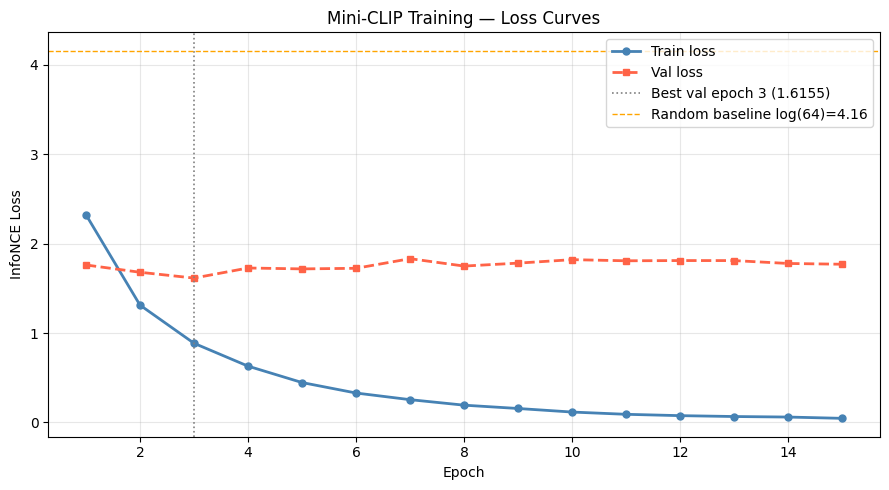

Saved to assets/loss_curves.png
Best epoch  : 3
Best val    : 1.6155
Train final : 0.0464


In [8]:
epochs_ran = len(loss_history['train'])
x = range(1, epochs_ran + 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x, loss_history['train'], 'o-', color='steelblue',
        linewidth=2, markersize=5, label='Train loss')
ax.plot(x, loss_history['val'],   's--', color='tomato',
        linewidth=2, markersize=5, label='Val loss')

# Mark best epoch
best_epoch = int(np.argmin(loss_history['val'])) + 1
best_loss  = min(loss_history['val'])
ax.axvline(best_epoch, color='grey', linestyle=':', linewidth=1.2,
           label=f'Best val epoch {best_epoch} ({best_loss:.4f})')

# Random baseline
baseline = math.log(CFG['batch_size'])
ax.axhline(baseline, color='orange', linestyle='--', linewidth=1,
           label=f'Random baseline log({CFG["batch_size"]})={baseline:.2f}')

ax.set_xlabel('Epoch')
ax.set_ylabel('InfoNCE Loss')
ax.set_title('Mini-CLIP Training — Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('assets/loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Saved to assets/loss_curves.png')
print(f'Best epoch  : {best_epoch}')
print(f'Best val    : {best_loss:.4f}')
print(f'Train final : {loss_history["train"][-1]:.4f}')

---
## Cell 8 — Temperature evolution over training

/tmp/ipykernel_7933/2354232651.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


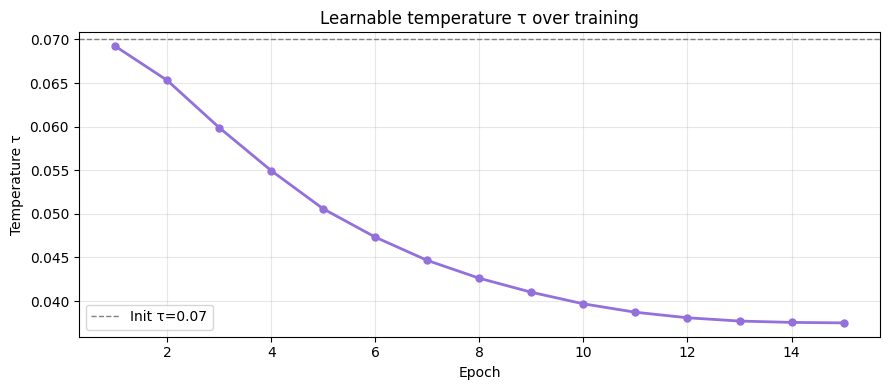

Initial τ : 0.0700
Final   τ : 0.0375


In [9]:
# Re-load all per-epoch checkpoints to extract temperature history
tau_history = []
for ep in range(epochs_ran):
    ckpt_path = os.path.join(CFG['checkpoint_dir'], f'epoch_{ep:02d}.pt')
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location='cpu')
        # Extract τ from the saved model state
        log_tau = ckpt['model_state']['log_temperature']
        tau_history.append(log_tau.exp().item())

if tau_history:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(range(1, len(tau_history)+1), tau_history,
            'o-', color='mediumpurple', linewidth=2, markersize=5)
    ax.axhline(0.07, color='grey', linestyle='--', linewidth=1, label='Init τ=0.07')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Temperature τ')
    ax.set_title('Learnable temperature τ over training')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('assets/temperature_history.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Initial τ : 0.0700')
    print(f'Final   τ : {tau_history[-1]:.4f}')

---
## Cell 9 — Confirm src/train.py import works

In [11]:
from src.train import train_epoch, validate, save_checkpoint, load_checkpoint

# Load best checkpoint using the src helper
model_check = CLIPModel(embedding_dim=CFG['embedding_dim']).to(device)
projection_params = (
    list(model_check.image_encoder.projection.parameters()) +
    list(model_check.text_encoder.projection.parameters())  +
    [model_check.log_temperature]
)
encoder_params = [
    p for p in model_check.parameters()
    if p.requires_grad and not any(p is pp for pp in projection_params)
]

# 3. Initialize the optimizer with the exact same 2-group list structure
opt_check = torch.optim.AdamW([
    {'params': encoder_params,    'lr': CFG['lr']},
    {'params': projection_params, 'lr': CFG['lr_head']},
])

ckpt = load_checkpoint(model_check, opt_check, CFG['best_ckpt_path'], device)

print('src.train import works correctly.')
print(f'Best checkpoint epoch  : {ckpt["epoch"] + 1}')
print(f'Best checkpoint val    : {ckpt["val_loss"]:.4f}')
print(f'Train history length   : {len(ckpt["loss_history"]["train"])} epochs')

src.train import works correctly.
Best checkpoint epoch  : 3
Best checkpoint val    : 1.6155
Train history length   : 3 epochs
